Import all necessary libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

Load Dataset

In [2]:
df = pd.read_csv("/content/amazon_sales_dataset.csv")

Explore the dataset

In [3]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [4]:
df.tail()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16
49999,50000,2023-06-29,2944,Home & Kitchen,253.44,30,1,Europe,Debit Card,2.1,464,177.41,177.41


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [6]:
df.shape

(50000, 13)

In [7]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


In [8]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')

In [12]:
df.isnull().sum()

,0
order_id,0
order_date,0
product_id,0
product_category,0
price,0
discount_percent,0
quantity_sold,0
customer_region,0
payment_method,0
rating,0


Data Cleaning(pandas)


Convert price into numeric

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.drop_duplicates()

In [16]:
df.duplicated().sum()

np.int64(0)

In [21]:
price_columns = [
    "price",
    "discounted_price",
    "total_revenue"
]

for col in price_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("₹", "", regex=False)
        .str.replace(",", "", regex=False)
    )

    df[col] = pd.to_numeric(df[col], errors="coerce")
print(df[col])

0         463.52
1        1210.40
2         793.28
3        1264.64
4         806.72
          ...   
49995     134.95
49996    1324.05
49997     985.92
49998     292.16
49999     177.41
Name: total_revenue, Length: 50000, dtype: float64


In [18]:
df.dtypes

,0
order_id,int64
order_date,object
product_id,int64
product_category,object
price,float64
discount_percent,int64
quantity_sold,int64
customer_region,object
payment_method,object
rating,float64


In [20]:
numeric_columns = [
    "discount_percent",
    "quantity_sold",
    "rating",
    "review_count"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
print(df[numeric_columns])

       discount_percent  quantity_sold  rating  review_count
0                    10              4     3.5           443
1                    20              5     3.7           475
2                    20              2     4.4           183
3                    15              4     5.0           212
4                     0              4     4.6           308
...                 ...            ...     ...           ...
49995                 0              5     2.4           386
49996                10              5     3.1             8
49997                30              4     3.1           104
49998                 5              1     1.8           316
49999                30              1     2.1           464

[50000 rows x 4 columns]


Convert Date column

In [23]:
df["order_date"] = pd.to_datetime(df["order_date"])
print(df['order_date'])

0       2022-04-13
1       2023-03-12
2       2022-09-28
3       2022-04-17
4       2022-03-13
           ...    
49995   2022-09-03
49996   2022-07-03
49997   2023-02-17
49998   2022-09-30
49999   2023-06-29
Name: order_date, Length: 50000, dtype: datetime64[ns]


Task 1 - Best Selling products

In [26]:
import os

os.makedirs("images", exist_ok=True)

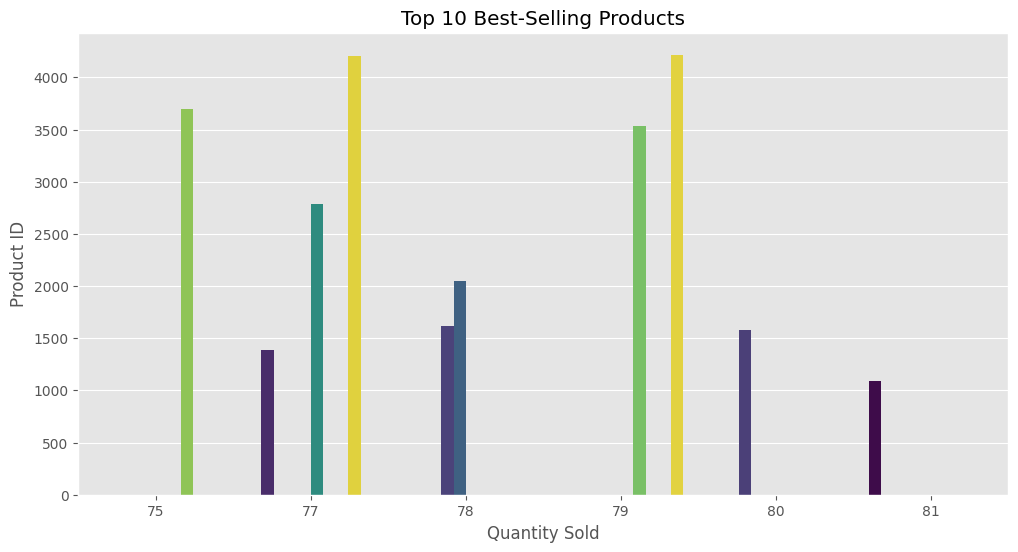

In [27]:
top_products = (
    df.groupby("product_id")["quantity_sold"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product ID")
plt.savefig("images/best_selling_products.png",dpi=300,bbox_inches="tight")
plt.show()


Task 2-Revenue by Category

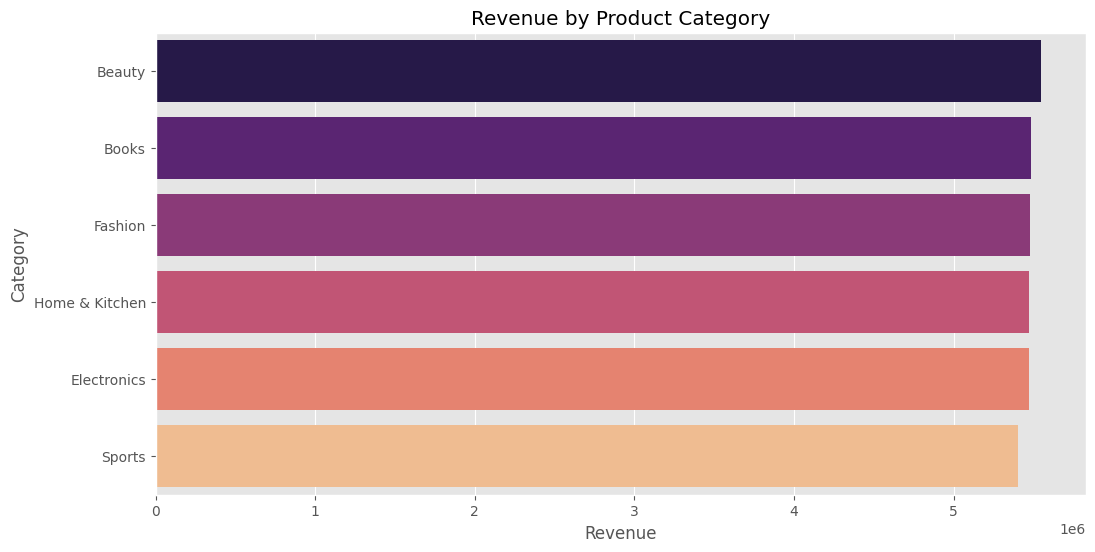

In [31]:
category_revenue = (
    df.groupby("product_category")["total_revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index,
    hue=category_revenue.index,
    palette="magma",
    legend=False
)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.savefig("images/revenue_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

Task 3-Customer ratings by category

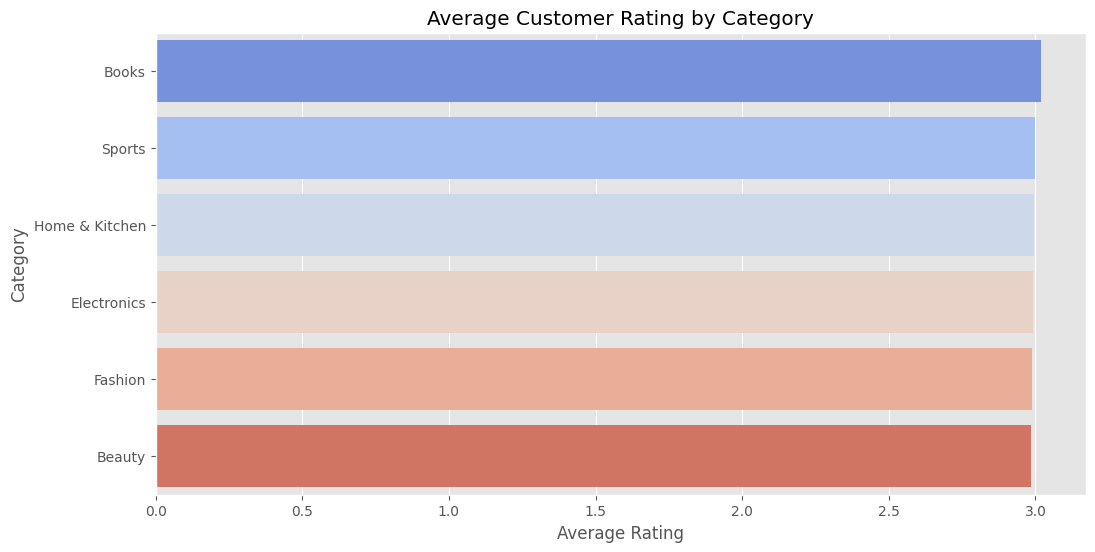

In [33]:
category_rating = (
    df.groupby("product_category")["rating"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_rating.values,
    y=category_rating.index,
    hue=category_rating.index,
    palette="coolwarm",
    legend=False
)

plt.title("Average Customer Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.savefig("images/customer_ratings.png", dpi=300, bbox_inches="tight")
plt.show()

Task 4 - Price Distribution

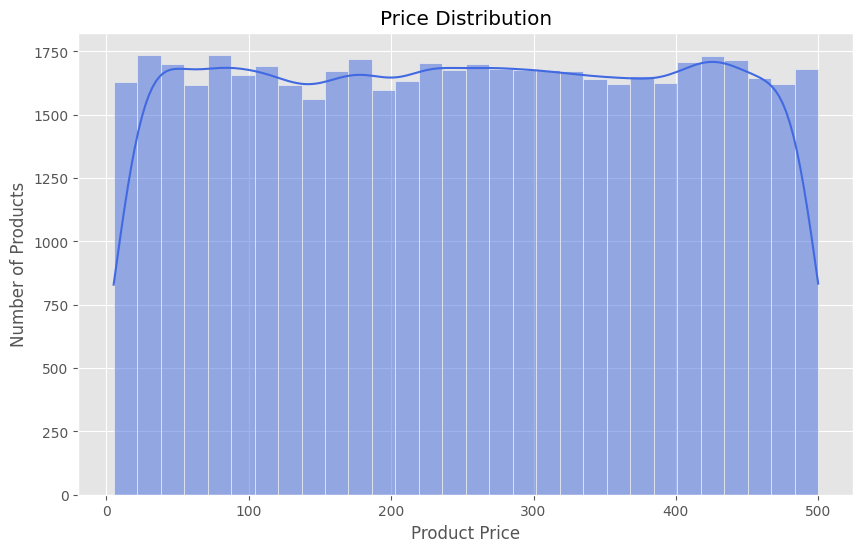

In [34]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["price"],
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Price Distribution")
plt.xlabel("Product Price")
plt.ylabel("Number of Products")
plt.savefig("images/price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Task 5 - Monthly Sales Trends

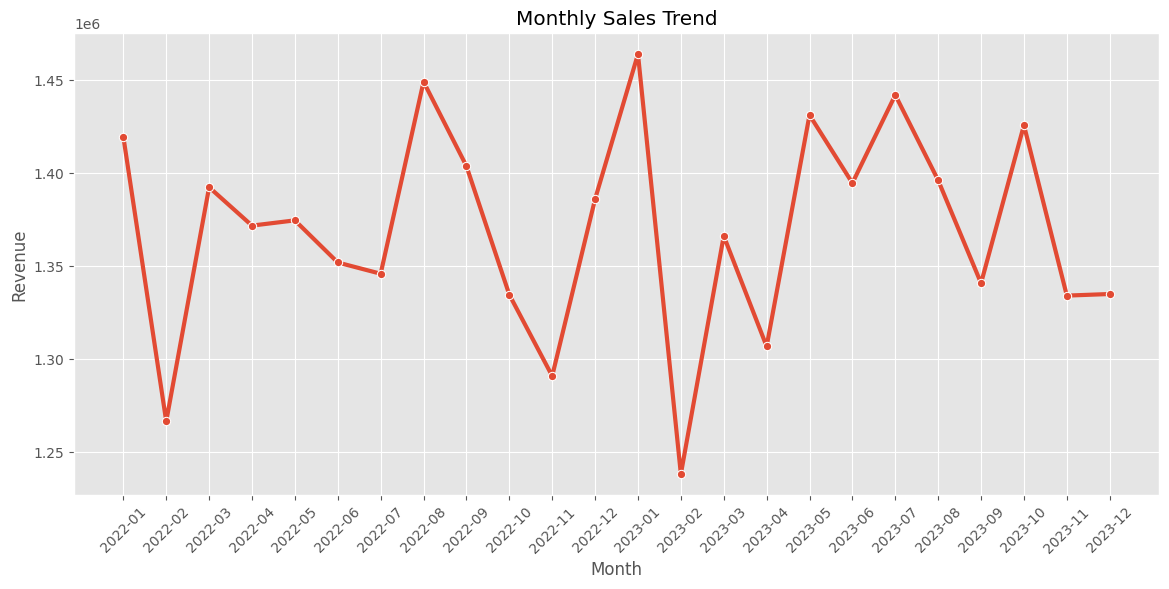

In [35]:
df["order_date"] = pd.to_datetime(df["order_date"])

df["Month"] = df["order_date"].dt.to_period("M").astype(str)

monthly_sales = (
    df.groupby("Month")["total_revenue"]
      .sum()
)

plt.figure(figsize=(14,6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o",
    linewidth=3
)
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.savefig("images/monthly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()

Task 6 - Discount Percentage Distribution

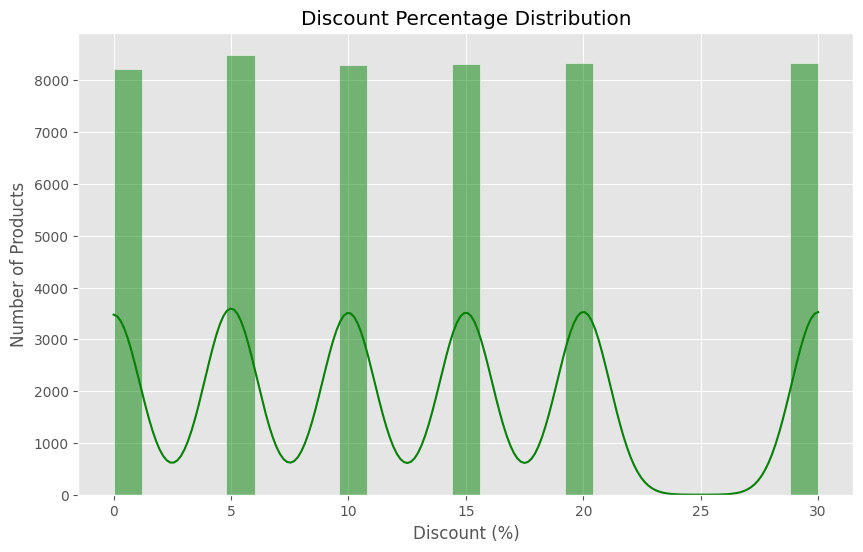

In [37]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["discount_percent"],
    bins=25,
    kde=True,
    color="green"
)

plt.title("Discount Percentage Distribution")
plt.xlabel("Discount (%)")
plt.ylabel("Number of Products")

plt.savefig("images/discount_percentage_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Task 7 - Correlation Heatmap

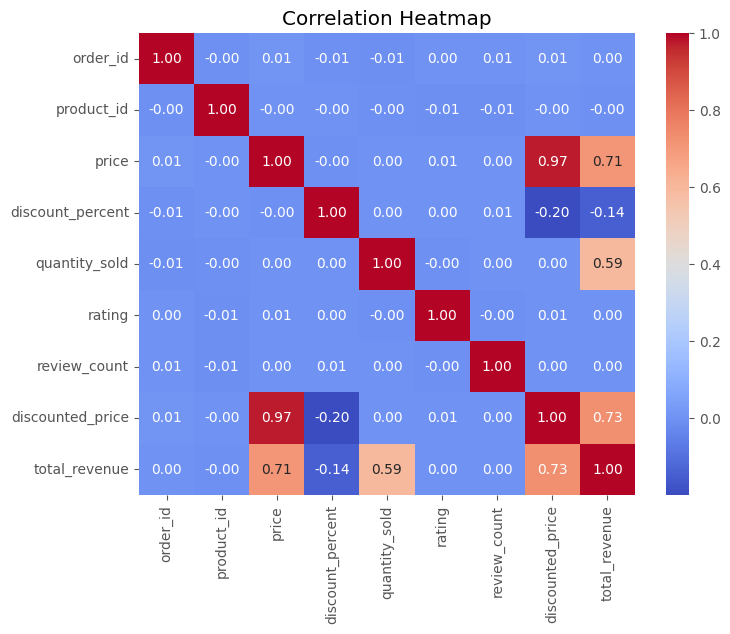

In [39]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=["int64","float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("images/correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Task 8 - Orders by Customer Region

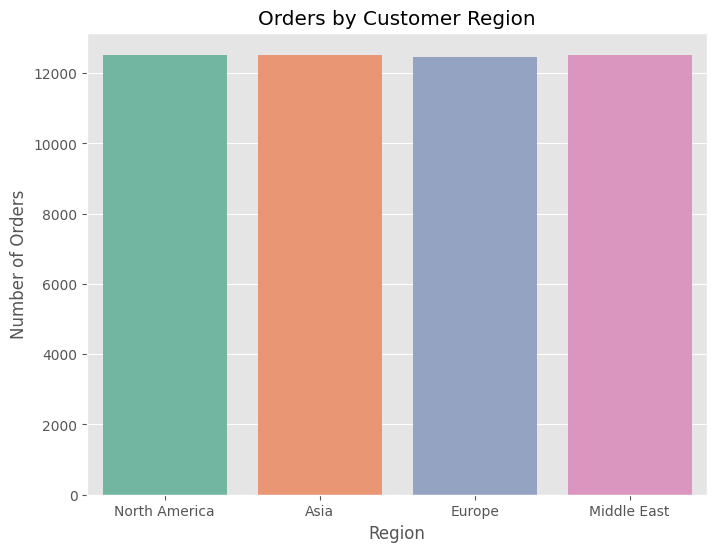

In [41]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="customer_region",
    hue="customer_region",
    palette="Set2",
    legend=False
)

plt.title("Orders by Customer Region")
plt.xlabel("Region")
plt.ylabel("Number of Orders")

plt.savefig("images/orders_by_customer_region.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Task 9 - Payment Method Analysis

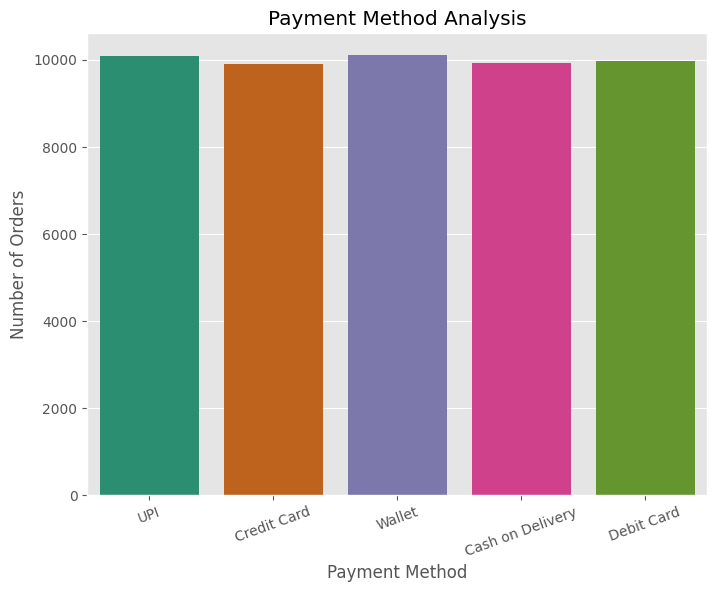

In [42]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="payment_method",
    hue="payment_method",
    palette="Dark2",
    legend=False
)

plt.title("Payment Method Analysis")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.xticks(rotation=20)

plt.savefig("images/payment_method_analysis.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Task 10 - Product Price Distribution by Category

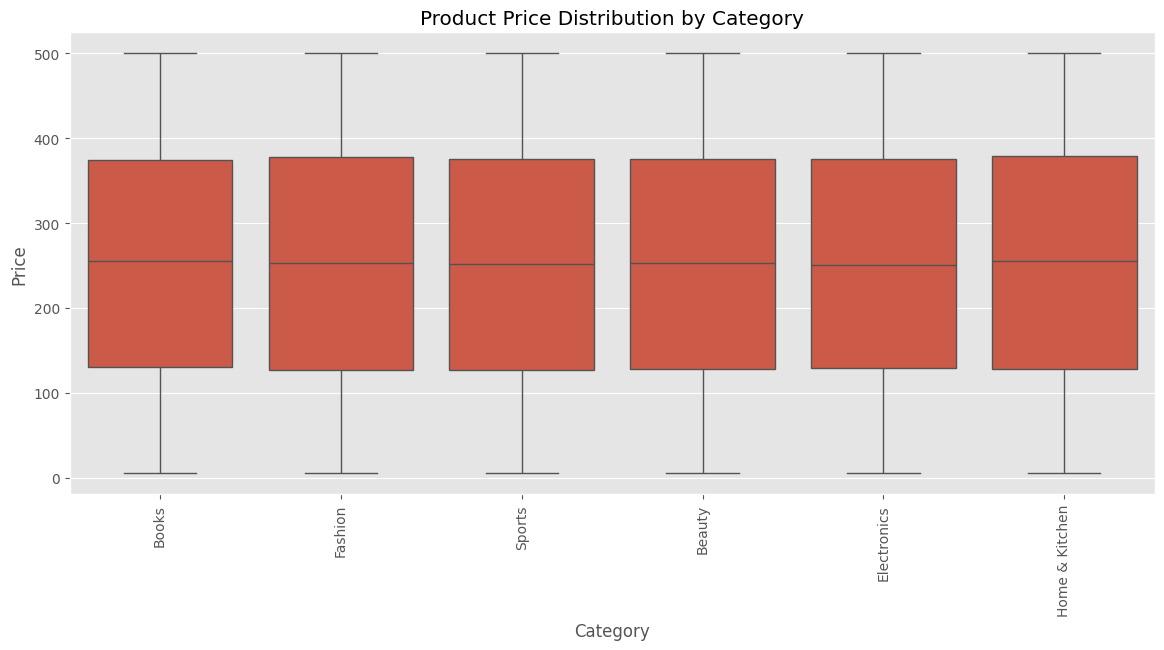

In [43]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x="product_category",
    y="price"
)

plt.xticks(rotation=90)

plt.title("Product Price Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Price")

plt.savefig("images/boxplot_product_prices.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [44]:
import shutil

shutil.make_archive("amazon_project_images", "zip", "images")

'/content/amazon_project_images.zip'

In [45]:
from google.colab import files

files.download("amazon_project_images.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>